In [1]:
#Import 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the iris dataset from Seaborn
iris = sns.load_dataset('iris')

# Extract the features and labels from the dataset
X = iris.iloc[:, :-1].values
y = iris.iloc[:, -1].values

In [3]:
# Convert the labels to integers
y[y == 'setosa'] = 0
y[y == 'versicolor'] = 1
y[y == 'virginica'] = 2

# Convert the features and labels to float32 data type
X = X.astype(np.float32)
y = y.astype(np.float32)

In [4]:
# Define the learning rate and number of epochs
lr = 0.1
n_epochs = 100

# Initialize the weights and bias to zero
w = np.zeros((X.shape[1], len(np.unique(y))))
b = np.zeros(len(np.unique(y)))

# Train the model using the Logistic Regression algorithm
for epoch in range(n_epochs):
    for i in range(X.shape[0]):
        z = np.dot(X[i], w) + b
        y_pred = np.argmax(z)
        if y_pred != y[i]:
            w[:, int(y[i])] += lr * X[i]
            w[:, int(y_pred)] -= lr * X[i]
            b[int(y[i])] += lr
            b[int(y_pred)] -= lr

In [5]:
# Make predictions on the test data and calculate the accuracy
z = np.dot(X, w) + b
y_pred = np.argmax(z, axis=1)
accuracy = (y_pred == y).sum() / len(y)

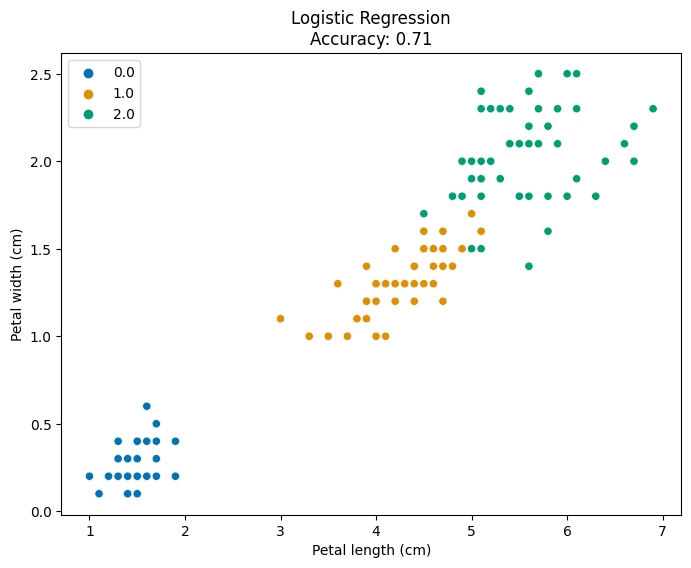

In [6]:
# Plot the decision regions and data points
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[:, 2], y=X[:, 3], hue=y, palette='colorblind')
plt.title(f'Logistic Regression\nAccuracy: {accuracy:.2f}')
plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.show()

Accuracy: 0.9


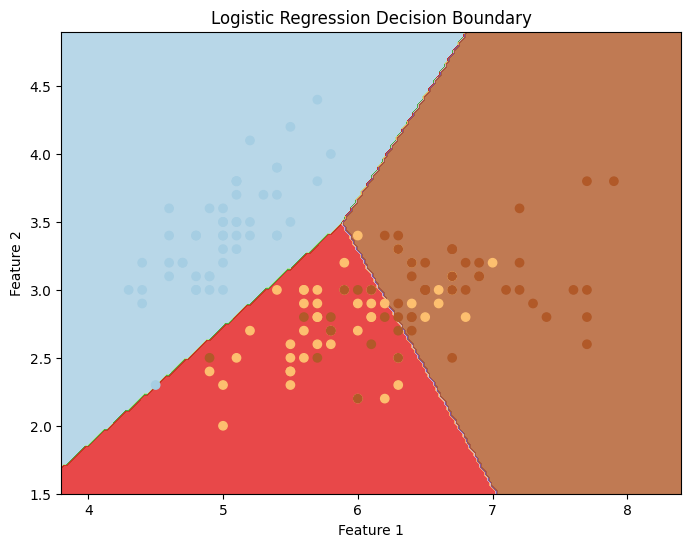

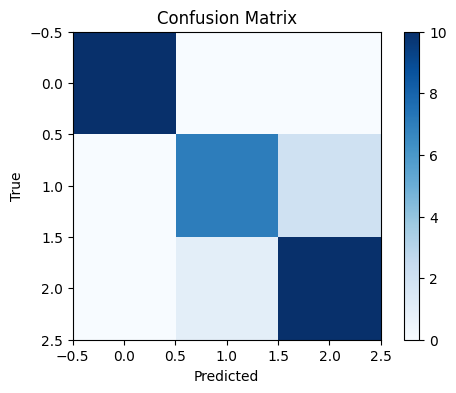

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.datasets import load_iris

# Load the dataset
iris = load_iris()
X = iris.data[:, :2]  # We will use only the first two features for visualization
y = iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create an instance of the LogisticRegression model
model = LogisticRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the testing data
y_pred = model.predict(X_test)

# Evaluate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Create a meshgrid to visualize the decision boundary
h = 0.02  # step size in the mesh
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Make predictions on the meshgrid points
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

# Plot the decision boundary and the data points
Z = Z.reshape(xx.shape)
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')
plt.show()

# Calculate and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()